# 1.Load Data

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv(r"C:\dev\kaggle_competition\titanic\data\train.csv")
test = pd.read_csv(r"C:\dev\kaggle_competition\titanic\data\test.csv")

# 2.EDA

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB


In [25]:
train.shape

(916, 12)

In [26]:
train.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [7]:
train_num = train.select_dtypes(include=np.number)
train_num.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,916.000000,916.000000,916.000000,736.000000,916.000000,916.000000,916.000000
mean,457.500000,0.377729,2.292576,29.698370,0.507642,0.361354,32.402710
std,264.570721,0.485084,0.838675,14.185627,1.044866,0.828054,50.506411
min,0.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,228.750000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,457.500000,0.000000,3.000000,28.000000,0.000000,0.000000,14.458300
75%,686.250000,1.000000,3.000000,38.000000,1.000000,0.000000,30.017700
max,915.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [8]:
train_str =train.select_dtypes(exclude=np.number)
train_str.describe()

,name,gender,ticket,cabin,embarked
count,916,916,916,198,915
unique,915,2,703,146,3
top,"Connolly, Miss. Kate",male,CA. 2343,B57 B59 B63 B66,S
freq,2,589,7,4,645


In [9]:
train['survived'].value_counts() / train.shape[0]

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

In [ ]:
train_str['embarked'].value_counts() #얘는 문자열 인코딩 할 수 있겠다. 

embarked
S    645
C    189
Q     81
Name: count, dtype: int64

In [11]:
train_str['cabin'].value_counts()

cabin
B57 B59 B63 B66    4
G6                 4
F2                 4
B96 B98            3
F33                3
                  ..
D11                1
C46                1
D22                1
C132               1
D38                1
Name: count, Length: 146, dtype: int64

In [ ]:
train_str['ticket'].value_counts()

ticket
CA. 2343        7
3101295         7
1601            7
CA 2144         6
S.O.C. 14879    6
               ..
2621            1
315091          1
28665           1
35852           1
PC 17606        1
Name: count, Length: 703, dtype: int64

ticket이랑 carbin은 뭔가 인코딩하기 어려우니까 먼저는 빼고 평가를 해보자.

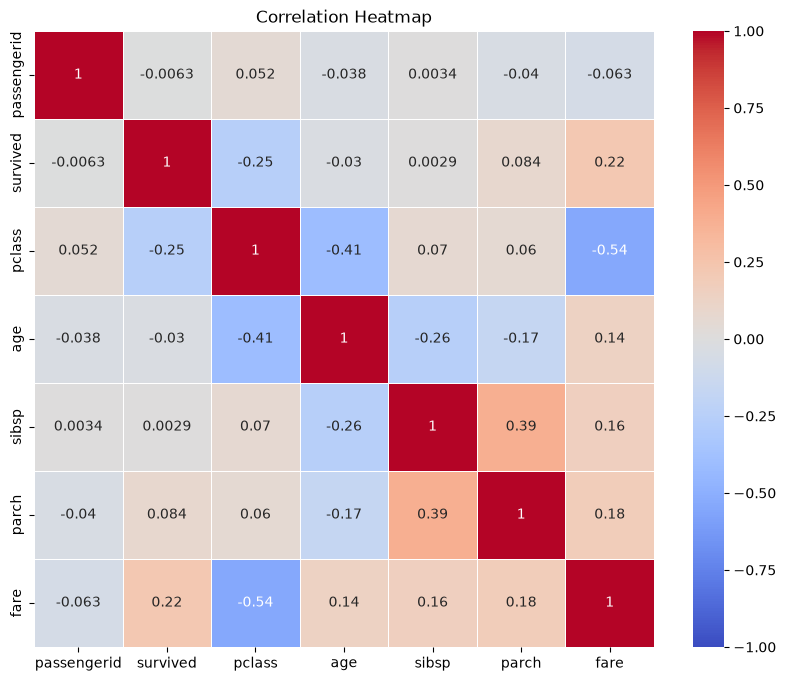

In [23]:
corr =train_num.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,          # 상관계수 숫자 표시
    cmap='coolwarm',     # 색상
    vmin=-1,
    vmax=1,              # 상관계수 범위 고정
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#feature끼리 상관관계 -> fare - pclass, age - pclass, age - sibsp, parch - sibsp
#feature vs target랑 상관관계 -> pclass, fare가 그나마 상관관계 높음

# 3.Data Preprocessing

In [ ]:
train.isnull().sum() / len(train)  

passengerid    0.000000
survived       0.000000
pclass         0.000000
name           0.000000
gender         0.000000
age            0.196507
sibsp          0.000000
parch          0.000000
ticket         0.000000
fare           0.000000
cabin          0.783843
embarked       0.001092
dtype: float64

## 결측치 채우기

In [36]:
train['age'] = train['age'].fillna(train['age'].mean())
train['age'].isnull().sum()

np.int64(0)

In [37]:
train['embarked'] = train['embarked'].fillna(train['embarked'].mode()[0])
train['embarked'].isnull().sum()

np.int64(0)

In [38]:
train.drop_duplicates(inplace=True)

In [39]:
train.drop(['name'],axis=1, inplace = True)

In [40]:
train.drop(['passengerid'],axis=1, inplace = True)

In [41]:
train.drop(['ticket'],axis=1, inplace = True)

In [ ]:
cat_cols = [
    'pclass', 'gender', 'embarked'
]

train[cat_cols] = train[cat_cols].astype('category')


In [49]:
x_tr = train.drop(['survived'],axis=1)
y_tr = train['survived']

x_tr.shape, y_tr.shape

((916, 7), (916,))

In [52]:
from sklearn.model_selection import train_test_split

x_tr,x_te,y_tr,y_te = train_test_split(
    x_tr,
    y_tr,
    test_size=0.2,
    random_state=42
)

In [54]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

xgb.fit(x_tr,y_tr)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [55]:
pred = xgb.predict(x_te)

In [56]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_te, pred))

0.7989974937343358
